In [125]:
from dotenv import load_dotenv
load_dotenv()

True

In [126]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import Literal
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import create_agent
from langchain.tools import tool


In [127]:
class FlowState(BaseModel):
    question: str = Field(description="User Asked Question")
    category: Literal["coding", "google_search", "weather"] = Field(default="google_search")
    answer: str = Field(default="")

class QuestionCategory(BaseModel):  
    category: Literal["coding", "google_search", "weather"] = Field(default="google_search", description="Question category")

llm = ChatGroq(model="llama-3.3-70b-versatile")

In [128]:
### Google Search Agent

search = GoogleSerperAPIWrapper(serper_api_key="793fe2b1c9b1b94b970427375bddce54af576491")
tools = [search.run]

google_agent = create_agent(
    model=llm, 
    tools=tools, 
    system_prompt="You are a agent and can search for any question on google."
)

### Weather Agent
@tool
def get_weather(city: str):   
    """It provides real time weather details for any city."""
    return f"The current temperature in {city} is 25°C."

weather_agent = create_agent(
    model=llm, 
    tools=[get_weather], 
    system_prompt="You are an agent and can provide real time weather details."
)

In [129]:
def check_question_category(state: FlowState) -> FlowState:
    st_llm = llm.with_structured_output(QuestionCategory)
    result = st_llm.invoke(f"I want to know category of my question, question is : '{state.question}'. If you are not sure then just give me 'google_search' as category.")
    state.category = result.category   
    print(result)

    return state
   

In [130]:
def route(state: FlowState) -> Literal["coding", "google_search", "weather"]:
    return state.category

In [131]:
def coding_node(state: FlowState) -> FlowState:
    print("Coding Node..")
    result = llm.invoke(f"You are a coding expert: {state.question}")
    state.answer = result.content
    return state

def weather_node(state: FlowState) -> FlowState:  
    response = weather_agent.invoke({"messages": [
        {"role": "user", "content": state.question}
    ]})
    
    state.answer = response["messages"][-1].content
    return state

def google_search_node(state: FlowState) -> FlowState:
    response = google_agent.invoke({"messages": [
        {"role": "user", "content": state.question}
    ]})    
    state.answer = response["messages"][-1].content
    return state

In [132]:
graph = StateGraph(FlowState)
graph.add_node("check_question_category", check_question_category)
graph.add_node("coding", coding_node)
graph.add_node("weather", weather_node)
graph.add_node("google_search", google_search_node)

graph.add_edge(START, "check_question_category")
graph.add_conditional_edges("check_question_category",  route)
graph.add_edge("coding", END)
graph.add_edge("weather", END)
graph.add_edge("google_search", END)

graph = graph.compile()

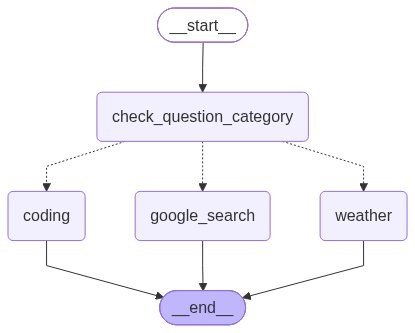

In [133]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [134]:
response = graph.invoke({"question": "What is 2 + 2"})

category='coding'
Coding Node..
